In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append("../../src")
from utils import write_extxyz

In [2]:
total_time = 10.0  # total simulation time
num_steps = 1000  # number of time steps
dt = total_time / num_steps  # time step size

In [3]:
num_particles = 10
initial_positions = np.random.rand(num_particles, 3)  # 10 particles in 3D
initial_velocities = np.random.rand(num_particles, 3)  # 10 particles
masses = np.ones(num_particles)  # mass of each particle

In [4]:
path = "verlet_simulation.xyz"
box = (10.0, 10.0, 10.0)  # simulation box dimensions
positions_T = np.zeros((num_steps, initial_positions.shape[0], 3))
positions_T[0] = initial_positions
write_extxyz(path, positions_T, box)

Wrote Extended XYZ: verlet_simulation.xyz


In [5]:
for t in range(1, num_steps):
    if t == 1:
        positions_T[t] = initial_positions + initial_velocities * dt
    else:
        positions_T[t] = positions_T[t - 1] + initial_velocities * dt

In [6]:
write_extxyz(path, positions_T, box)

Wrote Extended XYZ: verlet_simulation.xyz


In [7]:
positions = initial_positions.copy()


def compute_forces(positions, epsilon=1.0, sigma=1.0e-1, box=None):
    """
    Simple Lennard-Jones potential forces calculation.
    """
    forces = np.zeros_like(positions)  # No forces in this basic example
    for i in range(num_particles):
        force = np.zeros(3)
        for j in range(num_particles):
            if i != j:
                r_ij = positions[j] - positions[i]
                for dim in range(3):
                    box_length = box[dim]
                    if r_ij[dim] > box_length / 2:
                        r_ij[dim] -= box_length
                    elif r_ij[dim] < -box_length / 2:
                        r_ij[dim] += box_length
                r = np.linalg.norm(r_ij)
                if r > 0:
                    force += (
                        48 * epsilon * (sigma**12 / r**14)
                        - 24 * epsilon * (sigma**6 / r**8)
                    ) * r_ij
        forces[i] = force
    return forces


def compute_potential_energy(positions, epsilon=1.0, sigma=1.0e-1, box=None):
    """
    Simple Lennard-Jones potential energy calculation.
    """
    energy = 0.0
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            r_ij = positions[j] - positions[i]
            for dim in range(3):
                box_length = box[dim]
                if r_ij[dim] > box_length / 2:
                    r_ij[dim] -= box_length
                elif r_ij[dim] < -box_length / 2:
                    r_ij[dim] += box_length
            r = np.linalg.norm(r_ij)
            if r > 0:
                energy += 4 * epsilon * ((sigma / r) ** 12 - (sigma / r) ** 6)
    return energy

In [8]:
box = (10.0, 10.0, 10.0)  # simulation box dimensions
epsilon = 1.0
sigma = 1.0
positions_T = np.zeros((num_steps, initial_positions.shape[0], 3))
positions_T[0] = initial_positions
velocities_T = np.zeros((num_steps, initial_velocities.shape[0], 3))
velocities_T[0] = initial_velocities
velocities = initial_velocities.copy()
for t in range(1, num_steps):
    next_positions = positions_T[t - 1] + velocities * dt
    next_positions %= box  # Apply periodic boundary conditions
    positions_T[t] = next_positions
    velocities += (
        compute_forces(positions_T[t - 1], epsilon=epsilon, sigma=sigma, box=box)
        / masses[:, np.newaxis]
        * dt
    )
    velocities_T[t] = velocities
path = "verlet_simulation_with_forces.xyz"
write_extxyz(path, positions_T, box)

Wrote Extended XYZ: verlet_simulation_with_forces.xyz


In [9]:
poteintial_energies = []
kinetic_energies = []
total_energies = []
for t in range(num_steps):
    pe = compute_potential_energy(positions_T[t], epsilon=epsilon, sigma=sigma, box=box)
    ke = 0.5 * np.sum(
        masses[:, np.newaxis] * velocities_T[t] ** 2
    )  # Kinetic energy: 1/2 m v^2
    poteintial_energies.append(pe)
    kinetic_energies.append(ke)
    total_energies.append(pe + ke)

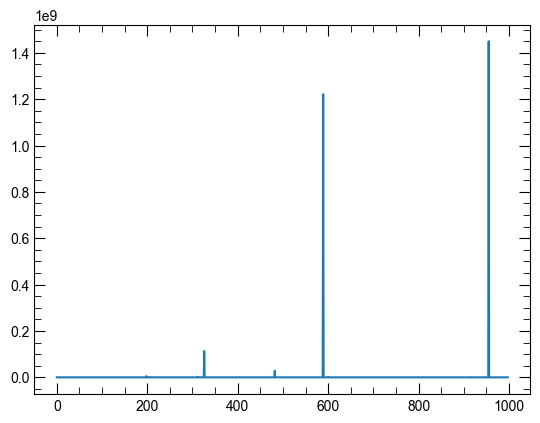

In [10]:
fig, ax = plt.subplots()
ax.plot(poteintial_energies[2:], label="Potential Energy")
# ax.plot(kinetic_energies, label="Kinetic Energy")
# ax.plot(total_energies, label="Total Energy")